# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/macro_stress_scenarios.csv
/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/portfolio_metrics.csv
/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/loan_portfolio.csv
/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/credit_ratings.csv
/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/vintage_analysis.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sergionefedov/credit-risk-dataset-50k-loans-10-sectors/macro_stress_scenarios.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,scenario,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,sector,base_pd,stressed_pd,pd_uplift_pp,pd_multiplier,base_lgd,stressed_lgd,total_ead,expected_loss_base,expected_loss_stress,el_increase_pct
0,baseline,0.0,0.0,0.0,0,Financials,0.022308,0.022308,0.0,1.0,0.45,0.45,3.016669e+10,3.161070e+08,3.028334e+08,-4.20
1,baseline,0.0,0.0,0.0,0,Real_Estate,0.022656,0.022656,0.0,1.0,0.40,0.40,2.530543e+10,2.617922e+08,2.293309e+08,-12.40
2,baseline,0.0,0.0,0.0,0,Consumer,0.021524,0.021524,0.0,1.0,0.55,0.55,5.049910e+09,6.904421e+07,5.978082e+07,-13.42
3,baseline,0.0,0.0,0.0,0,Industrials,0.021915,0.021915,0.0,1.0,0.50,0.50,1.571215e+10,1.963758e+08,1.721656e+08,-12.33
4,baseline,0.0,0.0,0.0,0,Technology,0.023575,0.023575,0.0,1.0,0.60,0.60,1.277305e+10,2.140718e+08,1.806719e+08,-15.60


## last Five row

In [4]:
df.tail()

,scenario,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,sector,base_pd,stressed_pd,pd_uplift_pp,pd_multiplier,base_lgd,stressed_lgd,total_ead,expected_loss_base,expected_loss_stress,el_increase_pct
55,covid_like,-8.0,8.0,-2.0,200,Energy,0.023161,0.063730,4.0569,2.752,0.45,0.5167,2.093550e+10,2.474053e+08,6.893415e+08,178.63
56,covid_like,-8.0,8.0,-2.0,200,Healthcare,0.022856,0.051771,2.8916,2.265,0.48,0.5467,1.004774e+10,1.182154e+08,2.843676e+08,140.55
57,covid_like,-8.0,8.0,-2.0,200,Utilities,0.022075,0.056714,3.4639,2.569,0.42,0.4867,2.206999e+10,2.358368e+08,6.091531e+08,158.29
58,covid_like,-8.0,8.0,-2.0,200,Retail,0.022869,0.054584,3.1714,2.387,0.58,0.6467,3.959381e+09,5.967482e+07,1.397557e+08,134.20
59,covid_like,-8.0,8.0,-2.0,200,Telecom,0.021696,0.054422,3.2726,2.508,0.50,0.5667,1.891039e+10,2.052627e+08,5.831827e+08,184.12


## Shape of our dataset

In [5]:
df.shape

(60, 16)

## List out all columns

In [6]:
df.columns

Index(['scenario', 'gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp',
       'credit_spread_bps', 'sector', 'base_pd', 'stressed_pd', 'pd_uplift_pp',
       'pd_multiplier', 'base_lgd', 'stressed_lgd', 'total_ead',
       'expected_loss_base', 'expected_loss_stress', 'el_increase_pct'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

scenario                 object
gdp_shock_pp            float64
unemp_shock_pp          float64
rate_shock_pp           float64
credit_spread_bps         int64
sector                   object
base_pd                 float64
stressed_pd             float64
pd_uplift_pp            float64
pd_multiplier           float64
base_lgd                float64
stressed_lgd            float64
total_ead               float64
expected_loss_base      float64
expected_loss_stress    float64
el_increase_pct         float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scenario              60 non-null     object 
 1   gdp_shock_pp          60 non-null     float64
 2   unemp_shock_pp        60 non-null     float64
 3   rate_shock_pp         60 non-null     float64
 4   credit_spread_bps     60 non-null     int64  
 5   sector                60 non-null     object 
 6   base_pd               60 non-null     float64
 7   stressed_pd           60 non-null     float64
 8   pd_uplift_pp          60 non-null     float64
 9   pd_multiplier         60 non-null     float64
 10  base_lgd              60 non-null     float64
 11  stressed_lgd          60 non-null     float64
 12  total_ead             60 non-null     float64
 13  expected_loss_base    60 non-null     float64
 14  expected_loss_stress  60 non-null     float64
 15  el_increase_pct       60 

## Check Null Value

In [9]:
df.isnull().sum()

scenario                0
gdp_shock_pp            0
unemp_shock_pp          0
rate_shock_pp           0
credit_spread_bps       0
sector                  0
base_pd                 0
stressed_pd             0
pd_uplift_pp            0
pd_multiplier           0
base_lgd                0
stressed_lgd            0
total_ead               0
expected_loss_base      0
expected_loss_stress    0
el_increase_pct         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,base_pd,stressed_pd,pd_uplift_pp,pd_multiplier,base_lgd,stressed_lgd,total_ead,expected_loss_base,expected_loss_stress,el_increase_pct
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01,6.000000e+01,6.000000e+01,60.000000
mean,-4.000000,3.833333,0.333333,183.333333,0.022464,0.037503,1.503988,1.669283,0.493000,0.526350,1.649302e+10,1.923786e+08,3.191250e+08,62.406000
std,2.715305,2.678645,1.638175,138.596679,0.000640,0.011801,1.175159,0.521787,0.063946,0.067835,8.225649e+09,8.068642e+07,1.949541e+08,58.434583
min,-8.000000,0.000000,-2.000000,0.000000,0.021524,0.021524,0.000000,1.000000,0.400000,0.400000,3.959381e+09,5.967482e+07,5.251826e+07,-15.600000
25%,-6.000000,1.500000,-1.000000,50.000000,0.021915,0.026955,0.441375,1.196000,0.450000,0.476900,1.004774e+10,1.182154e+08,1.704892e+08,9.992500
50%,-4.250000,4.000000,0.250000,175.000000,0.022482,0.036617,1.430800,1.629000,0.490000,0.516700,1.731127e+10,2.096672e+08,2.814203e+08,58.460000
75%,-1.500000,5.500000,1.500000,300.000000,0.022869,0.044442,2.165775,1.980000,0.550000,0.579400,2.206999e+10,2.474053e+08,4.493706e+08,95.970000
max,0.000000,8.000000,3.000000,400.000000,0.023575,0.063730,4.106300,2.812000,0.600000,0.666700,3.016669e+10,3.161070e+08,9.250109e+08,192.630000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

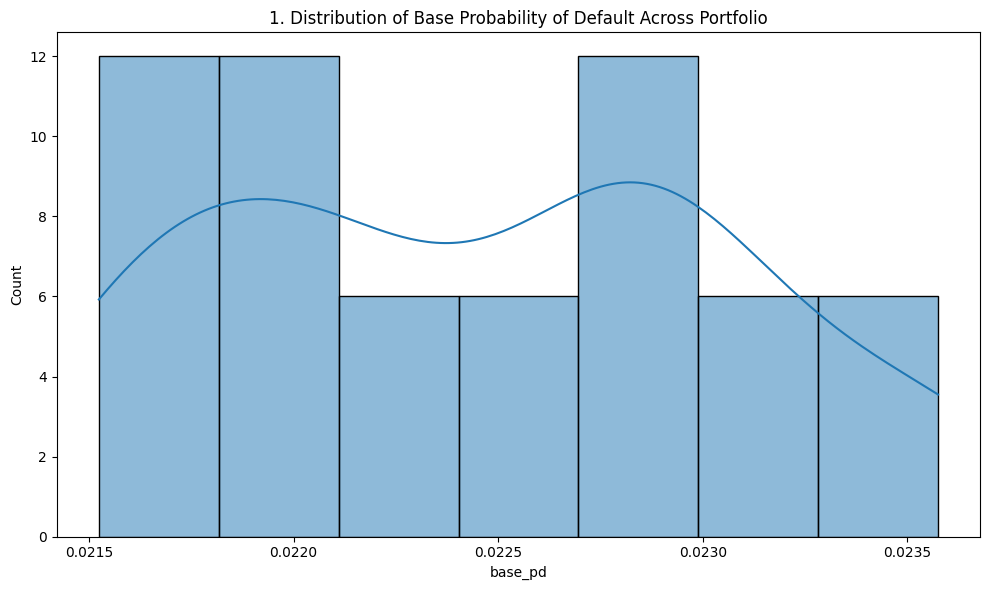

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['base_pd'], kde=True)
plt.title(f'{plot_no}. Distribution of Base Probability of Default Across Portfolio')
show_fig()
plot_no += 1

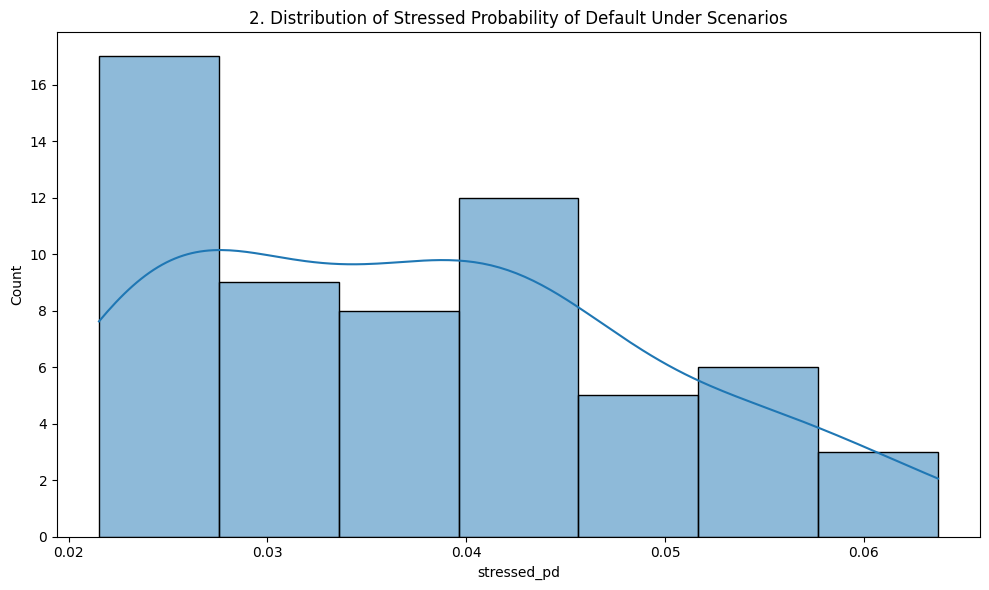

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['stressed_pd'], kde=True)
plt.title(f'{plot_no}. Distribution of Stressed Probability of Default Under Scenarios')
show_fig()
plot_no += 1

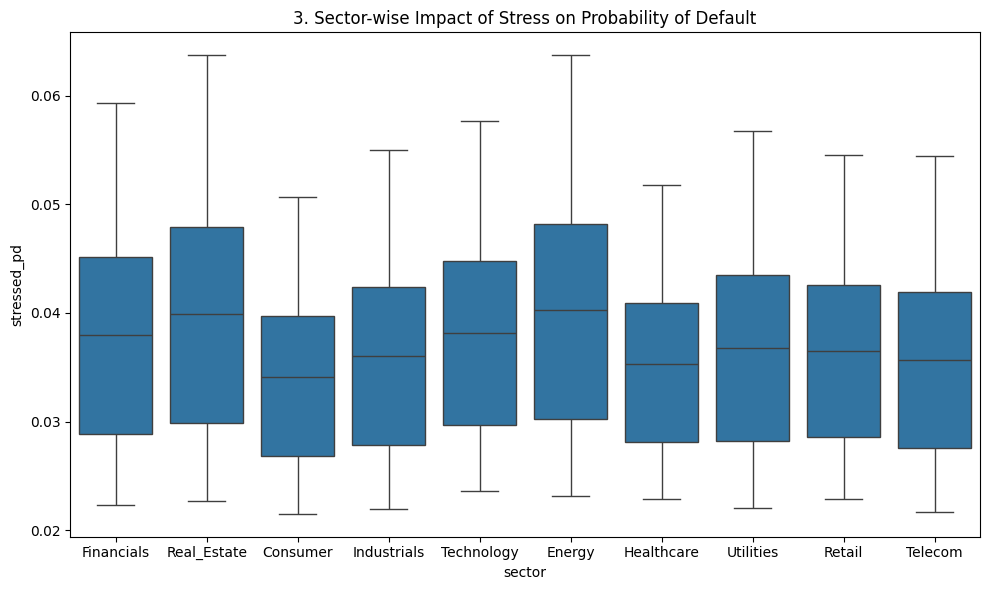

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='sector', y='stressed_pd', data=df)
plt.title(f'{plot_no}. Sector-wise Impact of Stress on Probability of Default')
show_fig()
plot_no += 1

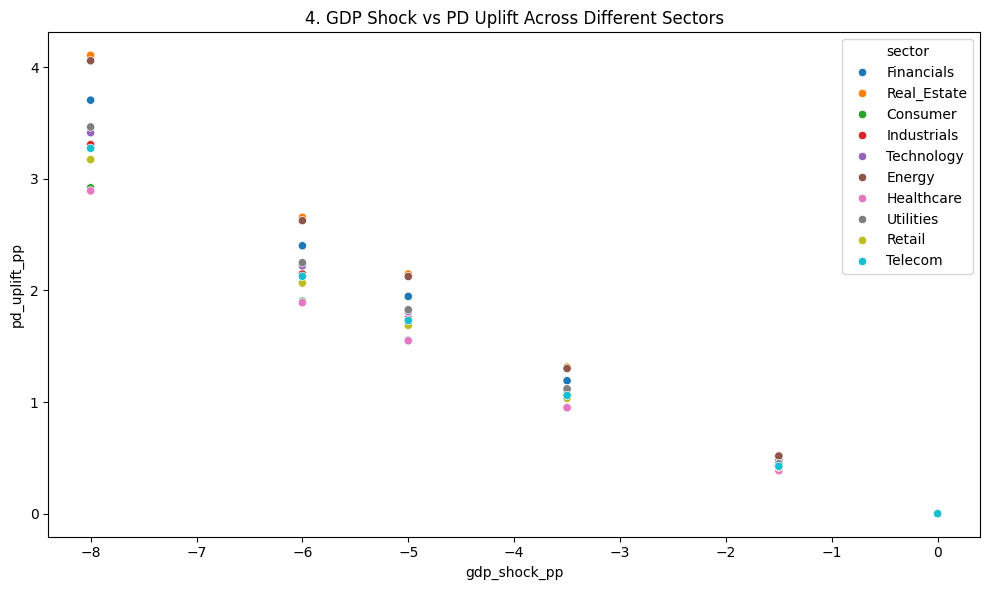

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gdp_shock_pp', y='pd_uplift_pp', hue='sector', data=df)
plt.title(f'{plot_no}. GDP Shock vs PD Uplift Across Different Sectors')
show_fig()
plot_no += 1

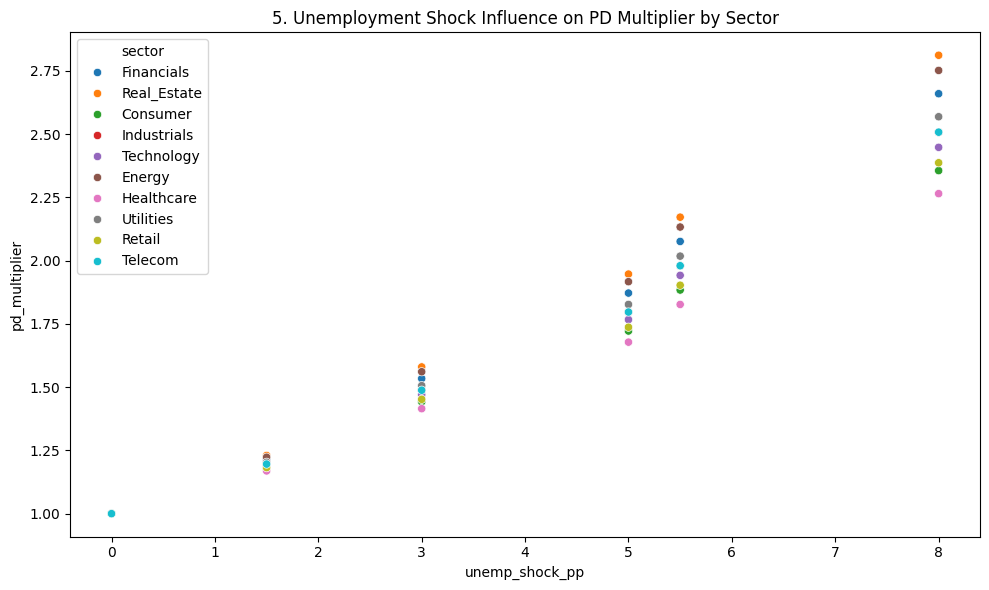

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='unemp_shock_pp', y='pd_multiplier', hue='sector', data=df)
plt.title(f'{plot_no}. Unemployment Shock Influence on PD Multiplier by Sector')
show_fig()
plot_no += 1

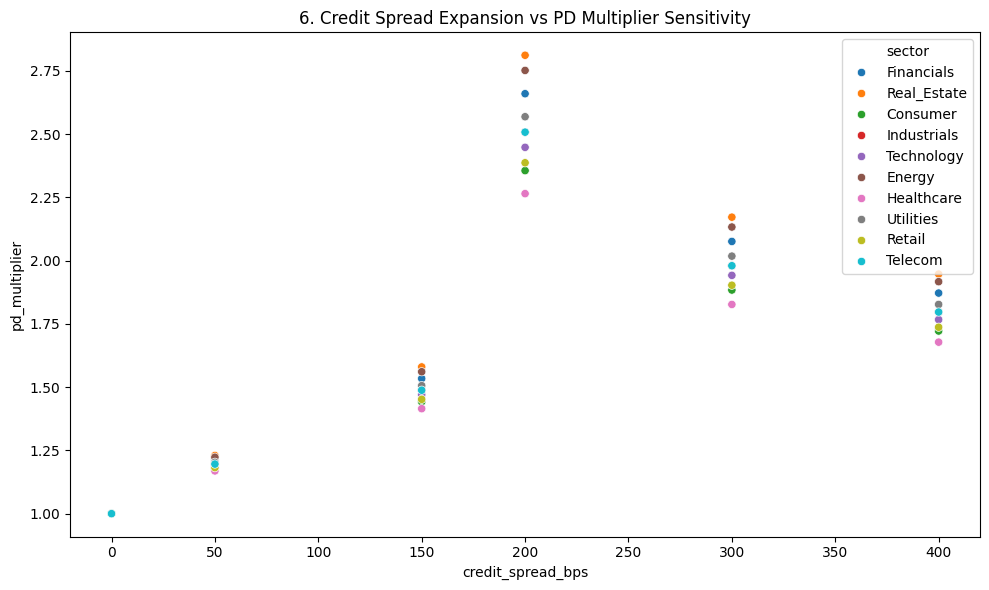

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='credit_spread_bps', y='pd_multiplier', hue='sector', data=df)
plt.title(f'{plot_no}. Credit Spread Expansion vs PD Multiplier Sensitivity')
show_fig()
plot_no += 1

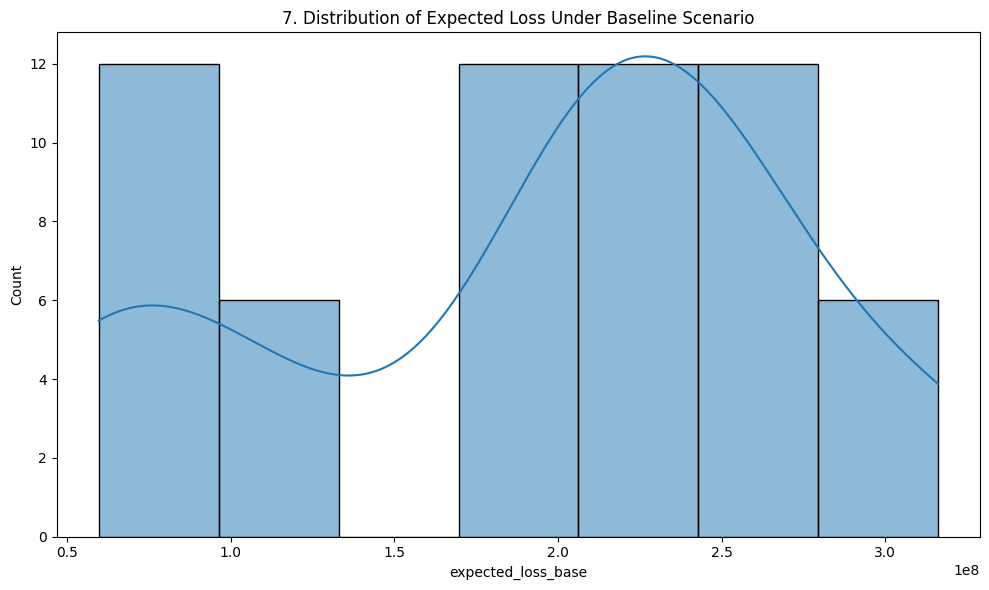

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['expected_loss_base'], kde=True)
plt.title(f'{plot_no}. Distribution of Expected Loss Under Baseline Scenario')
show_fig()
plot_no += 1

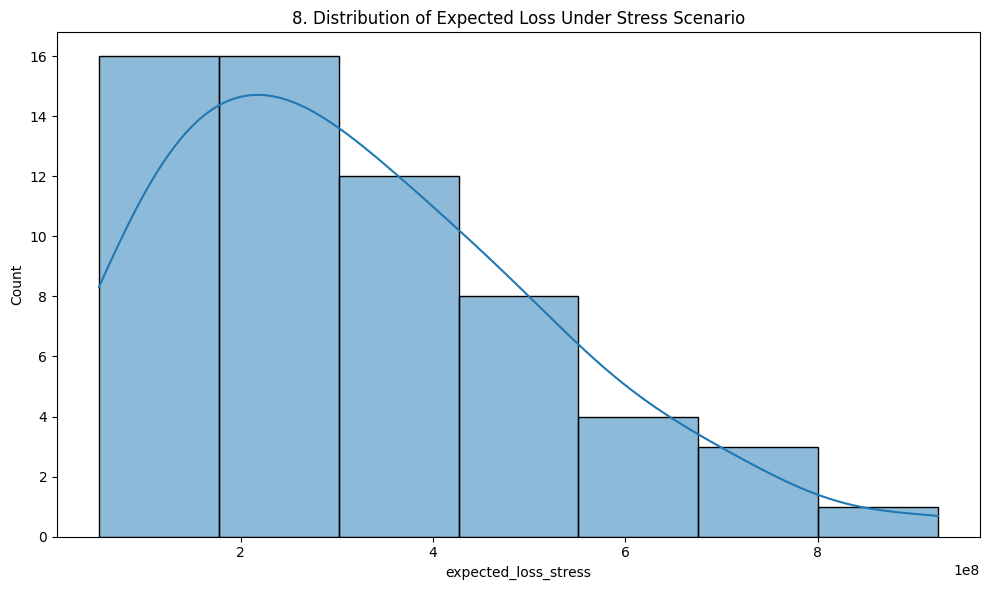

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['expected_loss_stress'], kde=True)
plt.title(f'{plot_no}. Distribution of Expected Loss Under Stress Scenario')
show_fig()
plot_no += 1

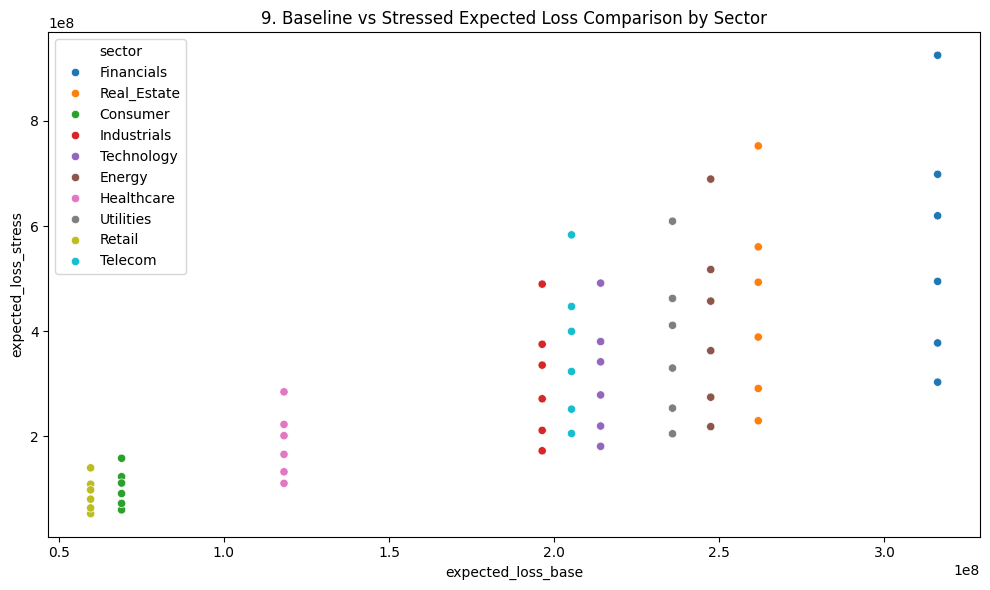

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='expected_loss_base', y='expected_loss_stress', hue='sector', data=df)
plt.title(f'{plot_no}. Baseline vs Stressed Expected Loss Comparison by Sector')
show_fig()
plot_no += 1

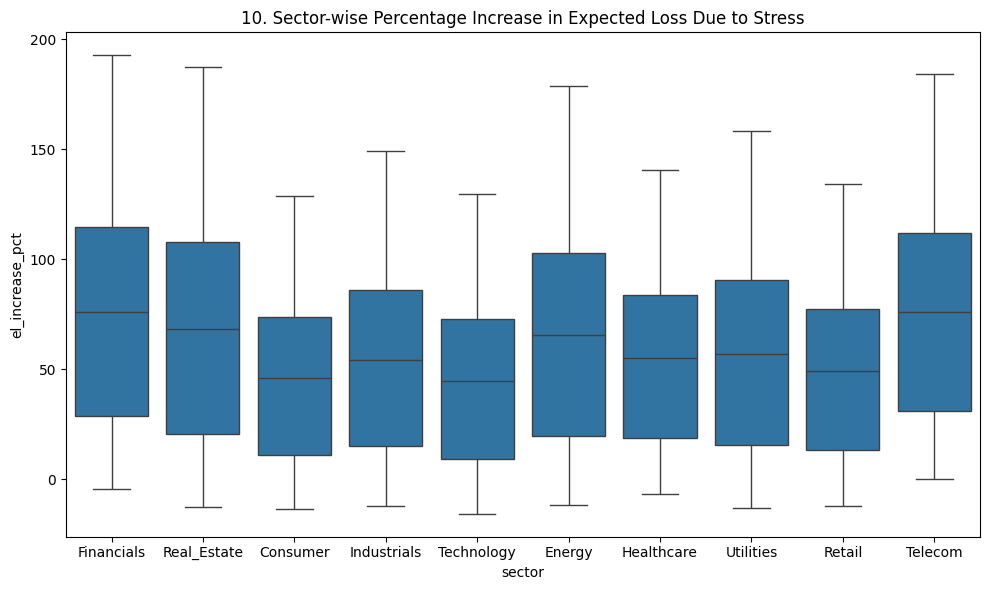

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='sector', y='el_increase_pct', data=df)
plt.title(f'{plot_no}. Sector-wise Percentage Increase in Expected Loss Due to Stress')
show_fig()
plot_no += 1

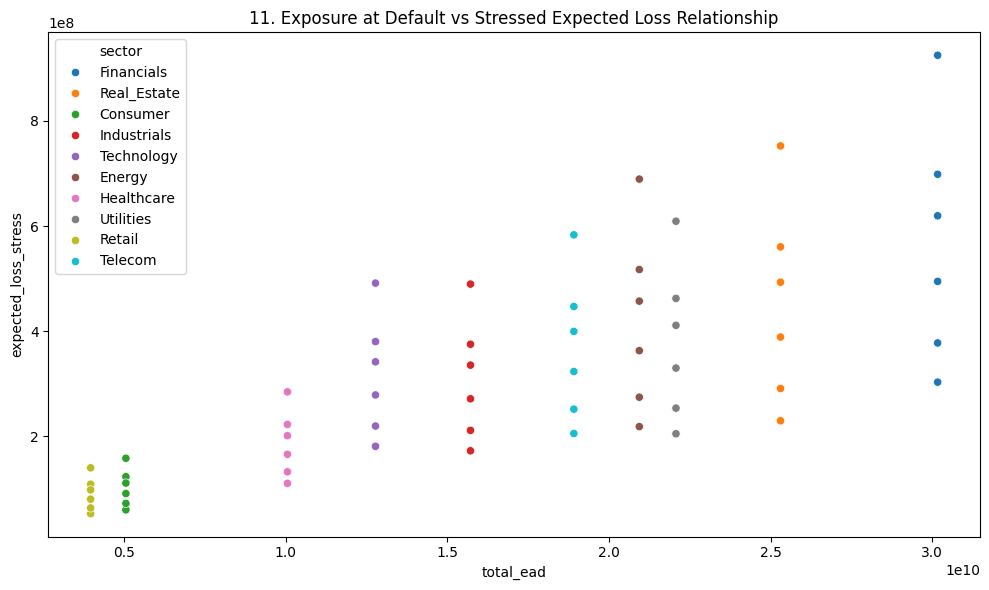

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='total_ead', y='expected_loss_stress', hue='sector', data=df)
plt.title(f'{plot_no}. Exposure at Default vs Stressed Expected Loss Relationship')
show_fig()
plot_no += 1

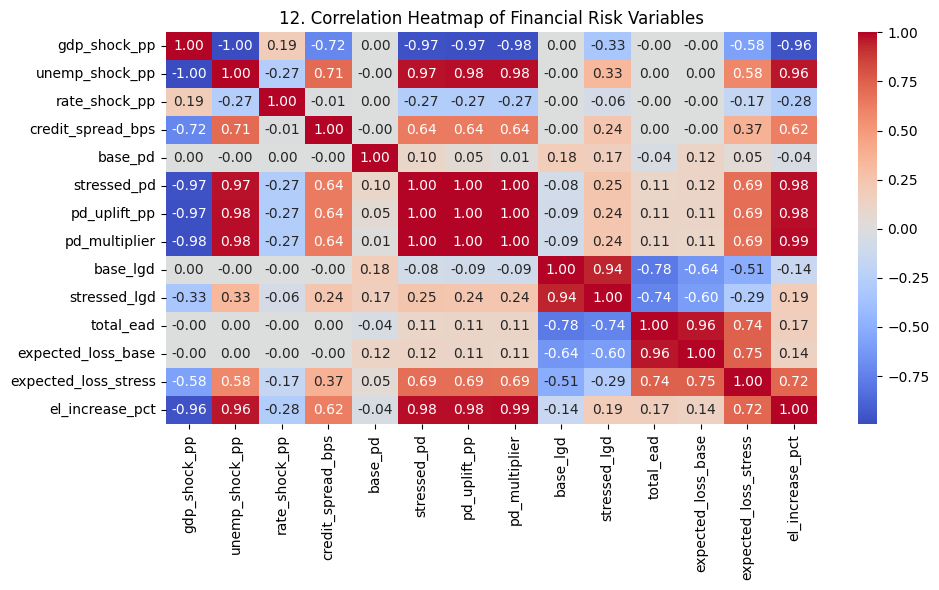

In [24]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Financial Risk Variables')
show_fig()
plot_no += 1

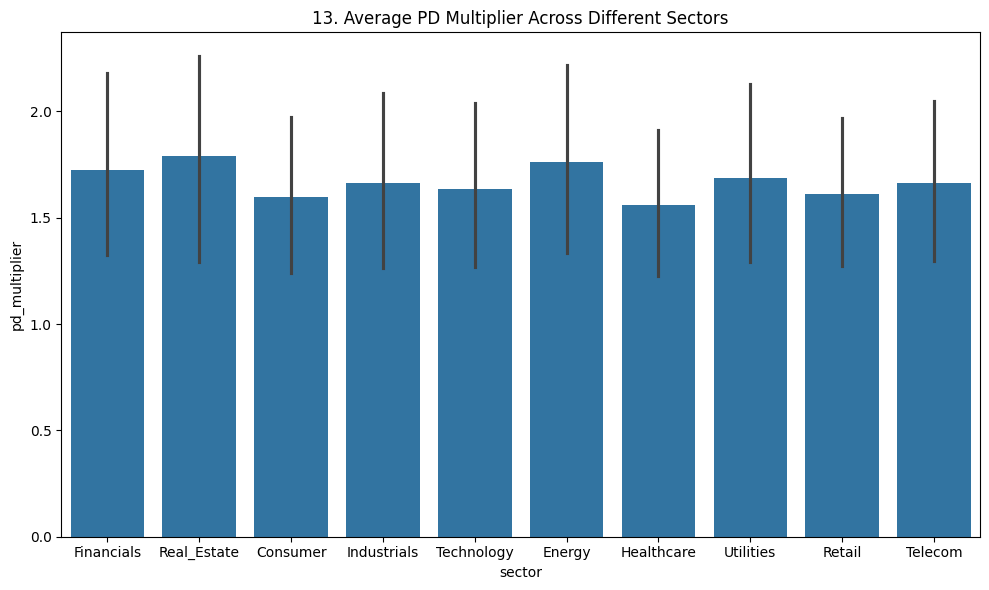

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='sector', y='pd_multiplier', data=df)
plt.title(f'{plot_no}. Average PD Multiplier Across Different Sectors')
show_fig()
plot_no += 1

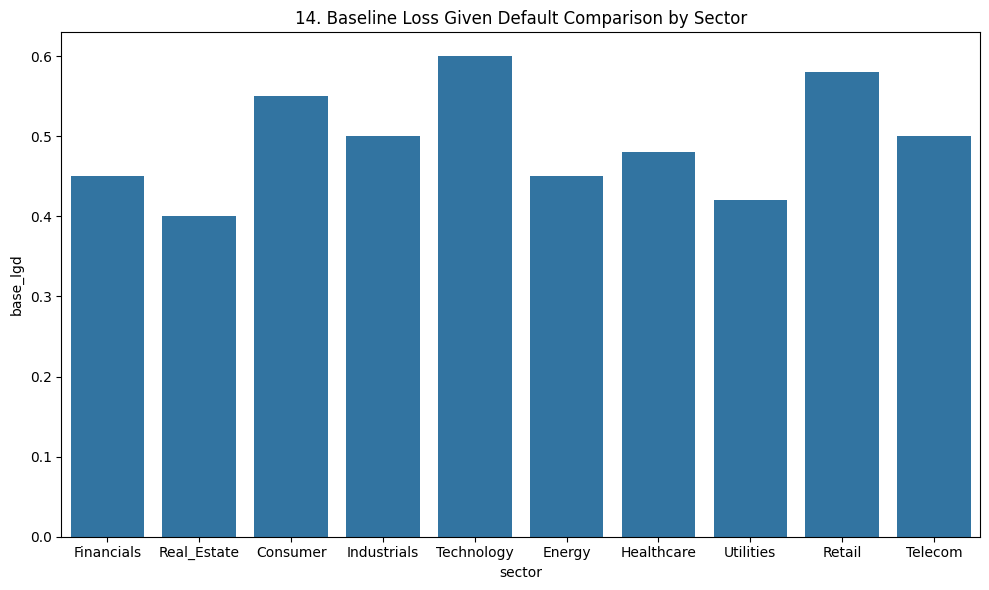

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='sector', y='base_lgd', data=df)
plt.title(f'{plot_no}. Baseline Loss Given Default Comparison by Sector')
show_fig()
plot_no += 1

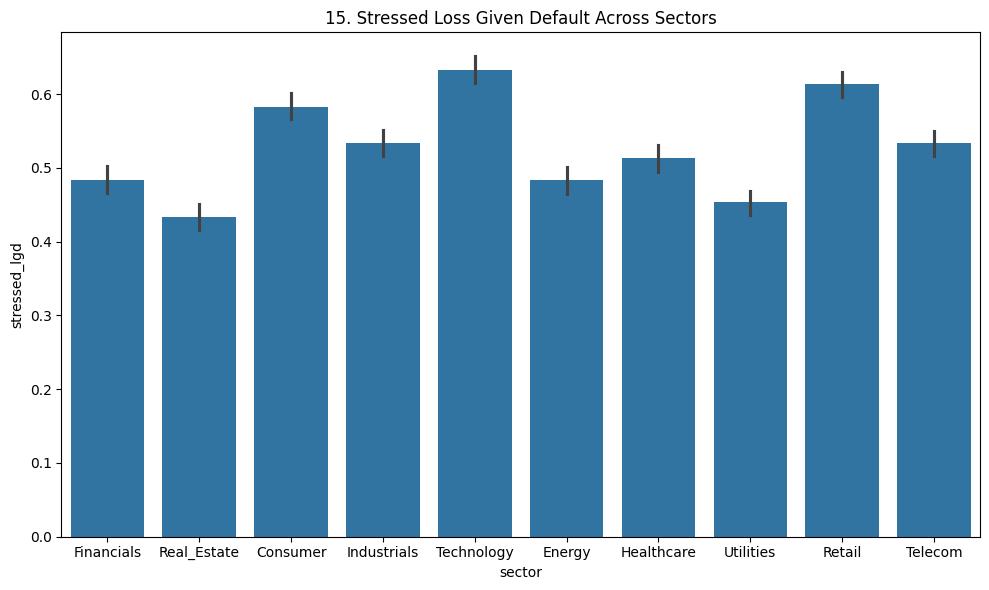

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='sector', y='stressed_lgd', data=df)
plt.title(f'{plot_no}. Stressed Loss Given Default Across Sectors')
show_fig()
plot_no += 1

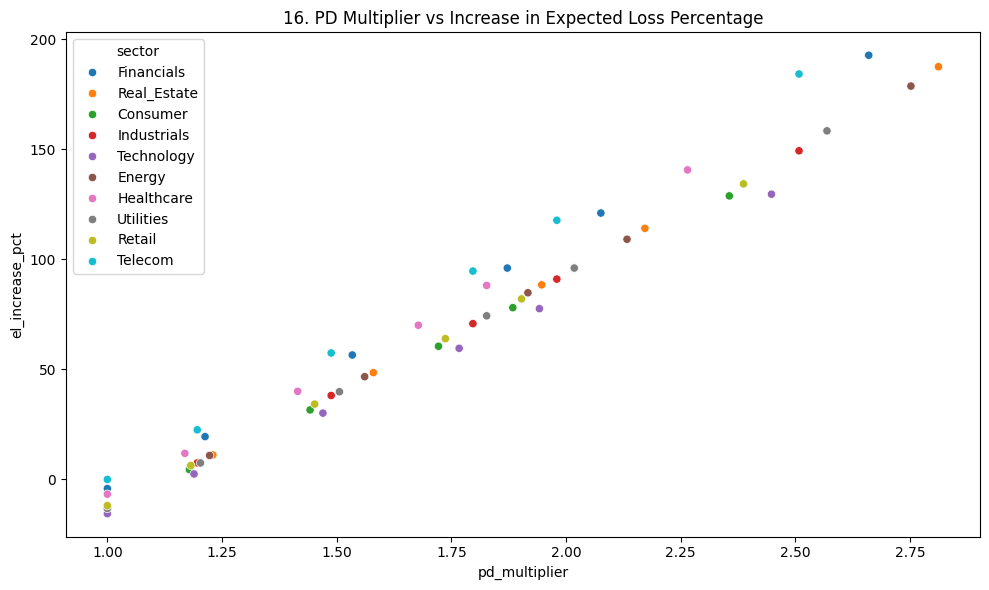

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='pd_multiplier', y='el_increase_pct', hue='sector', data=df)
plt.title(f'{plot_no}. PD Multiplier vs Increase in Expected Loss Percentage')
show_fig()
plot_no += 1

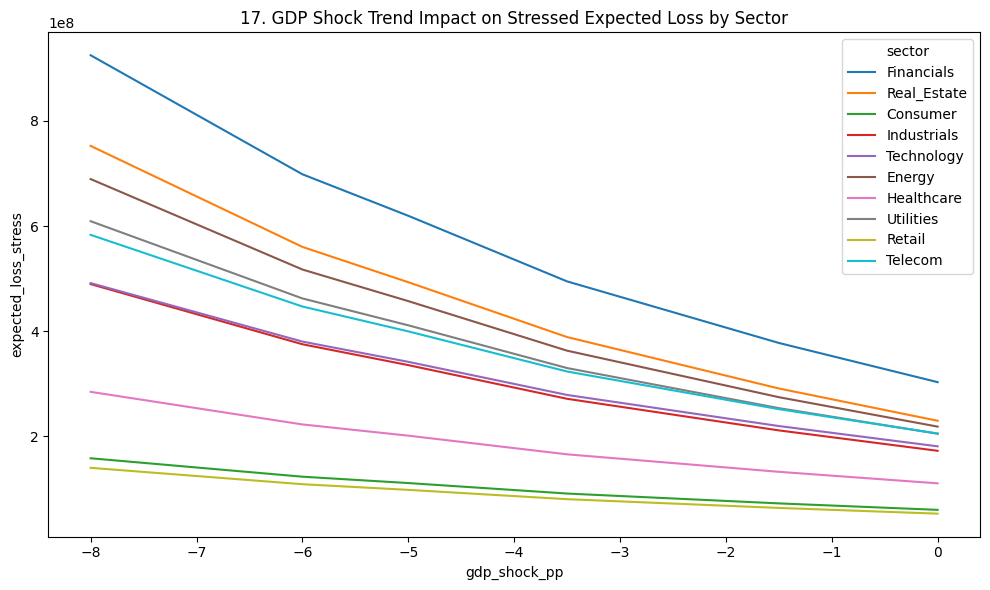

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='gdp_shock_pp', y='expected_loss_stress', hue='sector', data=df)
plt.title(f'{plot_no}. GDP Shock Trend Impact on Stressed Expected Loss by Sector')
show_fig()
plot_no += 1

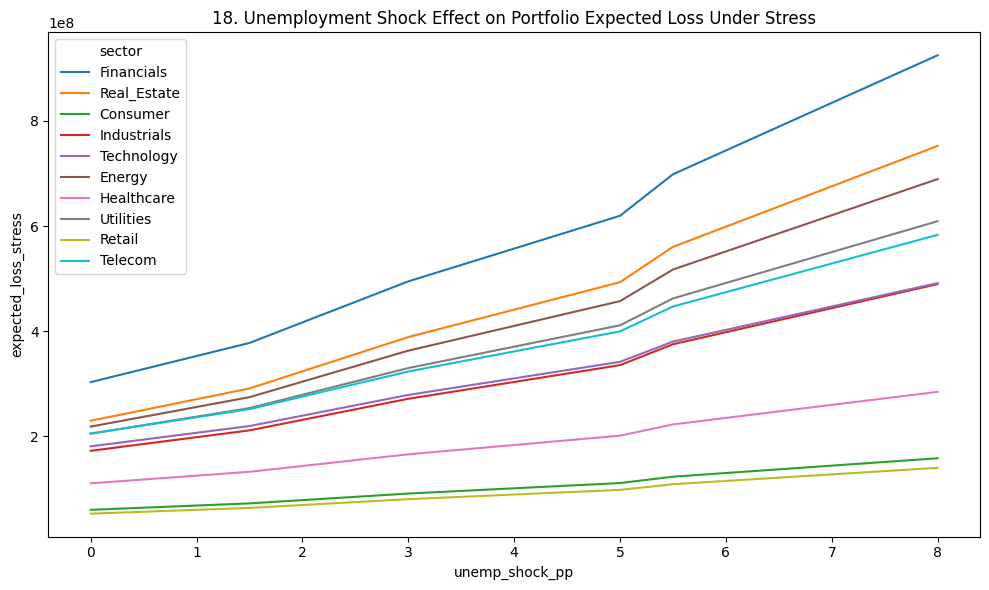

In [30]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='unemp_shock_pp', y='expected_loss_stress', hue='sector', data=df)
plt.title(f'{plot_no}. Unemployment Shock Effect on Portfolio Expected Loss Under Stress')
show_fig()
plot_no += 1

# Model Training

## define features and target (classification based on loss increase)

In [31]:
X = df[['gdp_shock_pp','unemp_shock_pp','rate_shock_pp','credit_spread_bps',
        'base_pd','stressed_pd','pd_uplift_pp','pd_multiplier',
        'base_lgd','stressed_lgd','total_ead','expected_loss_base','expected_loss_stress']]

y = (df['el_increase_pct'] > 0).astype(int)

## split dataset into train and test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## scale the features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train logistic regression model

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [35]:
y_pred = model.predict(X_test)

## print accuracy score

## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

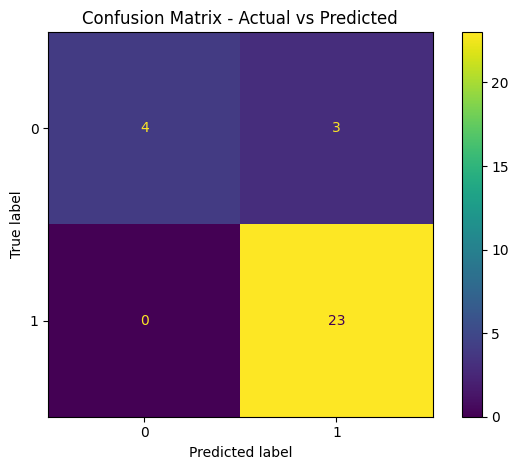

In [37]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Actual vs Predicted")
plt.tight_layout()
plt.show()